In [3]:
%load_ext autoreload
%autoreload 2

from difmap_wrapper import DifmapSession

In [4]:
session = DifmapSession()

In [5]:
fichier_fits = "tests/test_data/0003-066_X.SPLIT.1"
session.observe(fichier_fits)

Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e+07          1      1.6e+07
 

In [4]:
session.obs.select("I")

Selecting polarization: RR,  channels: 1..4
Reading IF 1 channels: 1..1


Polarization I is unavailable.


Reading IF 2 channels: 2..2
Reading IF 3 channels: 3..3
Reading IF 4 channels: 4..4


In [6]:
# Test de la nouvelle architecture !
session.vis.uvplot(interactive=True)

Aucune donnée UV. Appelez select() avant uvplot().


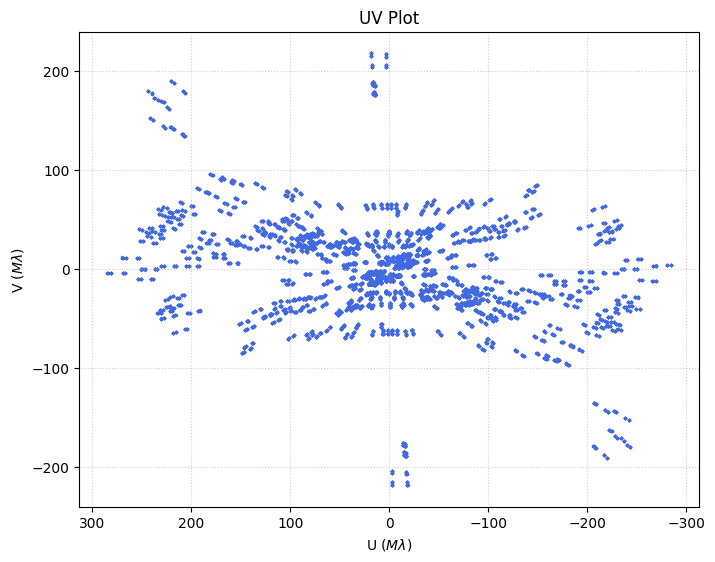

<Axes: title={'center': 'UV Plot'}, xlabel='U ($M\\lambda$)', ylabel='V ($M\\lambda$)'>

In [9]:
session.vis.uvplot(title="UV Plot", color='royalblue', s=2, alpha=0.7)

In [11]:
# --- 1. CONFIGURATION DE BASE (NATURELLE) ---
with DifmapSession() as session:
    session.observe(fichier_fits)
    session.obs.select(pol="RR")
    
    # On génère la carte naturelle (sans taper, poids par défaut)
    pkg_naturel = session.imager.make_dirty_map(size=512, cellsize=0.1)
    
    beam_naturel = pkg_naturel['beam_data']
    bmaj_nat = pkg_naturel['info']['bmaj']
    
    # On recadre le faisceau (zoom sur le centre 64x64 pixels)
    h, w = beam_naturel.shape
    zoom = 32
    beam_nat_zoom = beam_naturel[h//2 - zoom : h//2 + zoom, w//2 - zoom : w//2 + zoom]

    print(f"Faisceau Naturel : BMAJ = {bmaj_nat:.4f} mas")

Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e+07          1      1.6e+07
 

Polarization I is unavailable.


Nouvelle pondération appliquée : bin_size=2.0, err_power=-1.0, radial=NonReading UV FITS file: tests/test_data/0003-066_X.SPLIT.1

AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1    

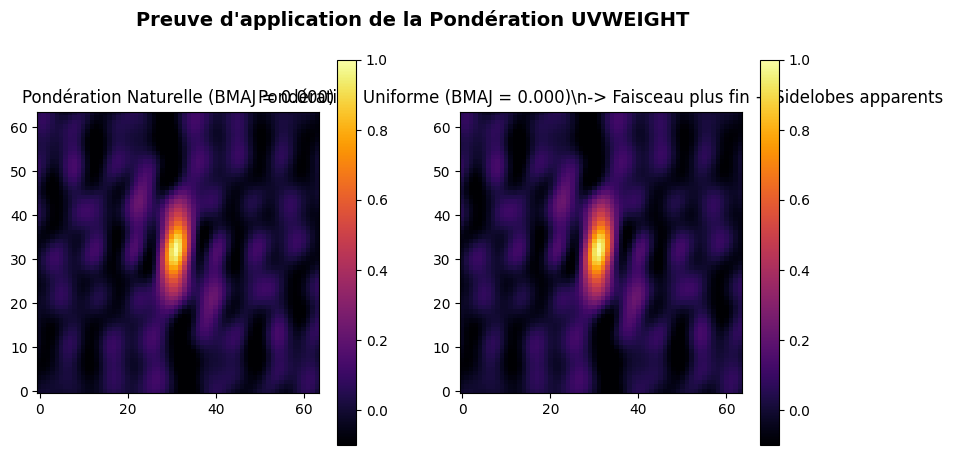

In [13]:
# --- 3. PREUVE DU UVWEIGHT (UNIFORME) ---
from matplotlib import pyplot as plt


with DifmapSession() as session:
    session.observe(fichier_fits)
    session.obs.select(pol="RR")
    session.imager.mapsize(512, 0.1)
    
    # Application du poids uniforme
    session.imager.uvweight(bin_size=2.0, err_power=-1.0)
    session.imager.invert()
    
    pkg_uniform = session.imager.get_map_package(cellsize=0.1)
    beam_uniform = pkg_uniform['beam_data']
    bmaj_uniform = pkg_uniform['info']['bmaj']
    
    beam_uni_zoom = beam_uniform[h//2 - zoom : h//2 + zoom, w//2 - zoom : w//2 + zoom]
    
    print(f"Faisceau Uniforme : BMAJ = {bmaj_uniform:.4f} mas")

# --- AFFICHAGE COMPARATIF WEIGHT ---
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Preuve d'application de la Pondération UVWEIGHT", fontsize=14, fontweight="bold")

img1 = axs[0].imshow(beam_nat_zoom, cmap='inferno', origin='lower', vmin=-0.1, vmax=1.0)
axs[0].set_title(f"Pondération Naturelle (BMAJ = {bmaj_nat:.3f})")
fig.colorbar(img1, ax=axs[0])

img2 = axs[1].imshow(beam_uni_zoom, cmap='inferno', origin='lower', vmin=-0.1, vmax=1.0)
axs[1].set_title(f"Pondération Uniforme (BMAJ = {bmaj_uniform:.3f})\\n-> Faisceau plus fin + Sidelobes apparents")
fig.colorbar(img2, ax=axs[1])

plt.show()

Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e+07          1      1.6e+07
 

uvgrid: No data in UV range.
uvgrid: No data in UV range.


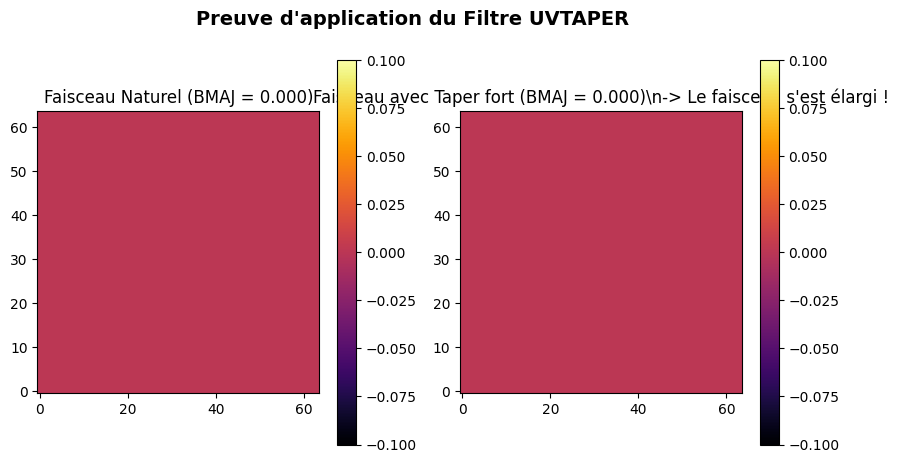

In [16]:
# --- 2. PREUVE DU UVTAPER (FLOU) ---
with DifmapSession() as session:
    session.observe(fichier_fits)
    session.obs.select(pol="RR")
    session.imager.mapsize(512, 0.1)
    
    # Application du Taper (extrêmement fort pour bien voir la différence)
    session.imager.uvtaper(0.25, 0.25)
    session.imager.invert()
    
    pkg_taper = session.imager.get_map_package(cellsize=0.1)
    beam_taper = pkg_taper['beam_data']
    bmaj_taper = pkg_taper['info']['bmaj']
    
    beam_tap_zoom = beam_taper[h//2 - zoom : h//2 + zoom, w//2 - zoom : w//2 + zoom]
    
    print(f"Faisceau avec Taper : BMAJ = {bmaj_taper:.4f} mas")

# --- AFFICHAGE COMPARATIF TAPER ---
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Preuve d'application du Filtre UVTAPER", fontsize=14, fontweight="bold")

img1 = axs[0].imshow(beam_nat_zoom, cmap='inferno', origin='lower')
axs[0].set_title(f"Faisceau Naturel (BMAJ = {bmaj_nat:.3f})")
fig.colorbar(img1, ax=axs[0])

img2 = axs[1].imshow(beam_tap_zoom, cmap='inferno', origin='lower')
axs[1].set_title(f"Faisceau avec Taper fort (BMAJ = {bmaj_taper:.3f})\\n-> Le faisceau s'est élargi !")
fig.colorbar(img2, ax=axs[1])

plt.show()

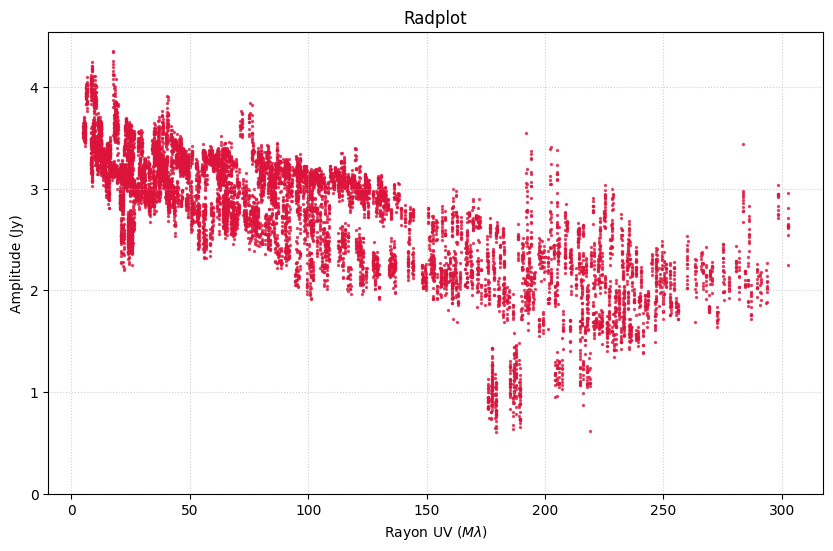

<Axes: title={'center': 'Radplot'}, xlabel='Rayon UV ($M\\lambda$)', ylabel='Amplitude (Jy)'>

In [10]:
session.vis.radplot(title="Radplot", color='crimson', s=2, alpha=0.7)

In [11]:
# 1. On s'assure que le fichier est chargé et qu'on sélectionne Stokes I
fichier_fits = "tests/test_data/0003-066_X.SPLIT.1" # Vérifie que ce chemin est bon !
session.observe(fichier_fits)
session.obs.select("I")

# 2. Maintenant on extrait les données au niveau du C
data = session.obs._native.get_uv_data()

# 3. On vérifie que le dictionnaire n'est pas vide avant de lire
if not data:
    print("Erreur : Toujours aucune donnée. Vérifiez le chemin du fichier FITS.")
else:
    print(f"Nombre total de points extraits : {len(data['u'])}")
    print(f"Première paire d'antennes : Antenne n°{data['tel_a'][0]} et Antenne n°{data['tel_b'][0]}")
    print(f"Sous-réseau du premier point : {data['subarray'][0]}")
    print(f"Timestamp du premier point : {data['time'][0]}")

Taper désactivé avec succès.
Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e

Polarization I is unavailable.
